# **GoogLeNet (Inception v1) Implementation on CIFAR-10**


---
## **Project Overview**
In this notebook, we implement the **GoogLeNet** architecture, famous for introducing the **Inception Module**.

### **Key Improvements in this Implementation:**
*   **Dimensionality Reduction:** 1x1 convolutions are used before 3x3 and 5x5 filters to reduce computational load.
*   **Functional API:** Since the network contains parallel paths that merge, we use the Keras `Model` API instead of `Sequential`.
*   **Global Average Pooling:** Replaces the heavy fully-connected layers to minimize the parameter count.
*   **Batch-Friendly Design:** Optimized for $32 \times 32$ images from the CIFAR-10 dataset.

In [1]:
# ─── ALL IMPORTS AT THE TOP ───────────────────────────────────────────────────

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import logging
tf.get_logger().setLevel(logging.ERROR)

EPOCHS = 50
BATCH_SIZE = 256

E0000 00:00:1778128293.862859    1331 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778128293.871514    1331 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778128293.893015    1331 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778128293.893039    1331 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778128293.893041    1331 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778128293.893043    1331 computation_placer.cc:177] computation placer already registered. Please check linka

## **1. Data Preprocessing and Augmentation**
1.  **Z-Score Normalization:** We standardize the images using the training mean and standard deviation.
2.  **Data Augmentation:** Horizontal flips and height/width shifts are applied to help the complex GoogLeNet architecture generalize better on small images.

In [2]:
# ─── 1. Load Dataset & Preprocessing ──────────────────────────────
cifar_dataset = keras.datasets.cifar10
(train_images, train_labels), (test_images, test_labels) = cifar_dataset.load_data()

mean   = np.mean(train_images)
stddev = np.std(train_images)
train_images = (train_images - mean) / stddev
test_images  = (test_images  - mean) / stddev

train_labels = to_categorical(train_labels, num_classes=10)
test_labels  = to_categorical(test_labels,  num_classes=10)

# Data Augmentation
datagen = ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(train_images)

## **2. Defining the Inception Module**
The Inception module allows the model to choose between different filter sizes ($1 \times 1, 3 \times 3, 5 \times 5$) in parallel. The results are concatenated at the end of the module.
*   **Branch 1:** $1 \times 1$ Conv
*   **Branch 2:** $1 \times 1$ Conv (Reduction) $\rightarrow$ $3 \times 3$ Conv
*   **Branch 3:** $1 \times 1$ Conv (Reduction) $\rightarrow$ $5 \times 5$ Conv
*   **Branch 4:** Max Pooling $\rightarrow$ $1 \times 1$ Conv (Projection)

In [3]:
def inception_module(x, filters_1x1, filters_3x3_reduce, filters_3x3, filters_5x5_reduce, filters_5x5, filters_pool_proj):
    # Branch 1
    conv_1x1 = Conv2D(filters_1x1, (1, 1), padding='same', activation='relu')(x)

    # Branch 2
    conv_3x3 = Conv2D(filters_3x3_reduce, (1, 1), padding='same', activation='relu')(x)
    conv_3x3 = Conv2D(filters_3x3, (3, 3), padding='same', activation='relu')(conv_3x3)

    # Branch 3
    conv_5x5 = Conv2D(filters_5x5_reduce, (1, 1), padding='same', activation='relu')(x)
    conv_5x5 = Conv2D(filters_5x5, (5, 5), padding='same', activation='relu')(conv_5x5)

    # Branch 4
    pool_proj = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    pool_proj = Conv2D(filters_pool_proj, (1, 1), padding='same', activation='relu')(pool_proj)

    # Concatenate
    output = concatenate([conv_1x1, conv_3x3, conv_5x5, pool_proj], axis=-1)
    return output

## **3. Building the GoogLeNet Architecture**
The architecture consists of the **Stem** (initial processing), the **Body** (stack of Inception modules), and the **Head** (Global Average Pooling and Softmax).

In [4]:
input_layer = Input(shape=(32, 32, 3))

# STEM
x = Conv2D(64, (3, 3), padding='same', activation='relu')(input_layer)
x = Conv2D(192, (3, 3), padding='same', activation='relu')(x)
x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

# BODY (Inception 3a, 3b, 4a, 4b, 4c, 4d, 4e, 5a, 5b)
x = inception_module(x, 64, 96, 128, 16, 32, 32)
x = inception_module(x, 128, 128, 192, 32, 96, 64)
x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

x = inception_module(x, 192, 96, 208, 16, 48, 64)
x = inception_module(x, 160, 112, 224, 24, 64, 64)
x = inception_module(x, 128, 128, 256, 24, 64, 64)
x = inception_module(x, 112, 144, 288, 32, 64, 64)
x = inception_module(x, 256, 160, 320, 32, 128, 128)
x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

x = inception_module(x, 256, 160, 320, 32, 128, 128)
x = inception_module(x, 384, 192, 384, 48, 128, 128)

# HEAD
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
output_layer = Dense(10, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(loss='categorical_crossentropy', optimizer=Adam(0.0001), metrics=['accuracy'])
model.summary()

I0000 00:00:1778128308.881827    1331 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │    110,784 │ conv2d[0][0]      │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     18,528 │ max_pooling2d[0]… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │      3,088 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ max_pooling2d[0]… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     12,352 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │    110,720 │ conv2d_3[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     12,832 │ conv2d_5[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │      6,176 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_2[0][0],   │
│ (Concatenate)       │ 256)              │            │ conv2d_4[0][0],   │
│                     │                   │            │ conv2d_6[0][0],   │
│                     │                   │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │     32,896 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 16, 16,    │      8,224 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │     32,896 │ concatenate[0][0] │
│                     │ 128)              │            │                 

 Total params: 5,971,962 (22.78 MB)

 Trainable params: 5,971,962 (22.78 MB)

 Non-trainable params: 0 (0.00 B)

## **4. Model Training**
Training is conducted over 50 epochs using the Adam optimizer.

In [5]:
history = model.fit(
    datagen.flow(train_images, train_labels, batch_size=BATCH_SIZE),
    validation_data=(test_images, test_labels),
    epochs=EPOCHS,
    verbose=2
)

Epoch 1/50


I0000 00:00:1778128322.845921    1394 service.cc:152] XLA service 0x7c2cc0004ca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778128322.845970    1394 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778128325.607181    1394 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778128360.301945    1394 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


196/196 - 139s - 708ms/step - accuracy: 0.2868 - loss: 1.8562 - val_accuracy: 0.3944 - val_loss: 1.6594
Epoch 2/50
196/196 - 56s - 284ms/step - accuracy: 0.4328 - loss: 1.5086 - val_accuracy: 0.4684 - val_loss: 1.3978
Epoch 3/50
196/196 - 56s - 288ms/step - accuracy: 0.4992 - loss: 1.3564 - val_accuracy: 0.5450 - val_loss: 1.2400
Epoch 4/50
196/196 - 56s - 287ms/step - accuracy: 0.5516 - loss: 1.2255 - val_accuracy: 0.6072 - val_loss: 1.0838
Epoch 5/50
196/196 - 56s - 287ms/step - accuracy: 0.5944 - loss: 1.1160 - val_accuracy: 0.6298 - val_loss: 1.0322
Epoch 6/50
196/196 - 56s - 288ms/step - accuracy: 0.6243 - loss: 1.0383 - val_accuracy: 0.6400 - val_loss: 1.0048
Epoch 7/50
196/196 - 56s - 288ms/step - accuracy: 0.6607 - loss: 0.9517 - val_accuracy: 0.6745 - val_loss: 0.9255
Epoch 8/50
196/196 - 57s - 289ms/step - accuracy: 0.6793 - loss: 0.8944 - val_accuracy: 0.7155 - val_loss: 0.7976
Epoch 9/50
196/196 - 57s - 289ms/step - accuracy: 0.6962 - loss: 0.8522 - val_accuracy: 0.7065 - v

## **5. Training Analysis**
Evaluation of the Loss, Accuracy, and Error rates to determine model performance and stability.

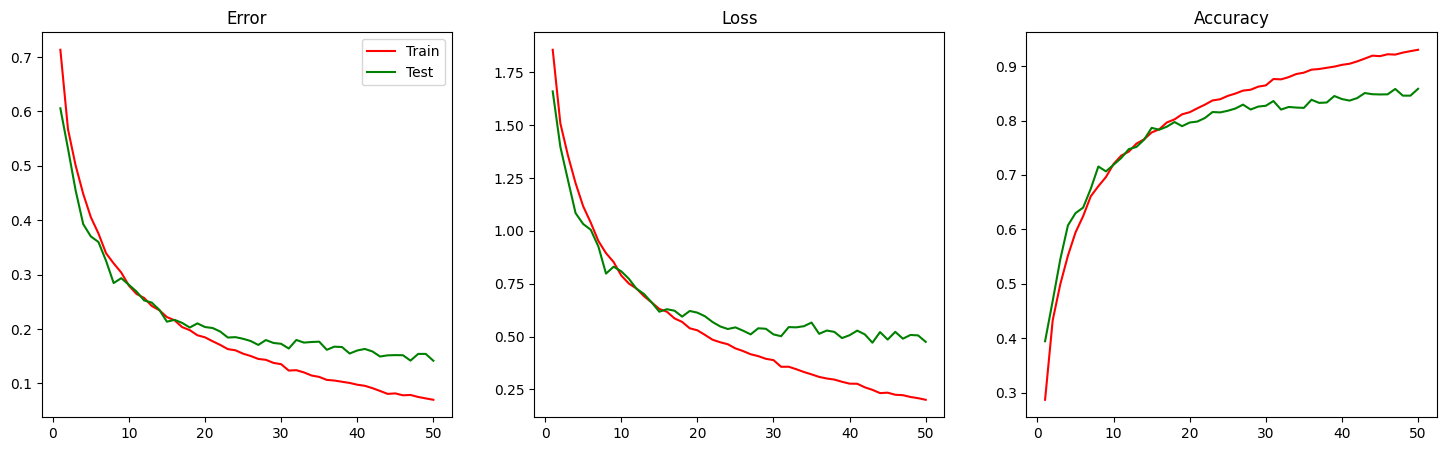

In [8]:
train_error = [1 - acc for acc in history.history['accuracy']]
test_error = [1 - acc for acc in history.history['val_accuracy']]
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1); plt.plot(epochs_range, train_error, 'r', label='Train'); plt.plot(epochs_range, test_error, 'g', label='Test'); plt.title('Error'); plt.legend()
plt.subplot(1, 3, 2); plt.plot(epochs_range, history.history['loss'], 'r'); plt.plot(epochs_range, history.history['val_loss'], 'g'); plt.title('Loss')
plt.subplot(1, 3, 3); plt.plot(epochs_range, history.history['accuracy'], 'r'); plt.plot(epochs_range, history.history['val_accuracy'], 'g'); plt.title('Accuracy')
plt.show()

## **6. Visual Predictions and Confusion Matrix**
Final qualitative and quantitative evaluation of the GoogLeNet model.

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step


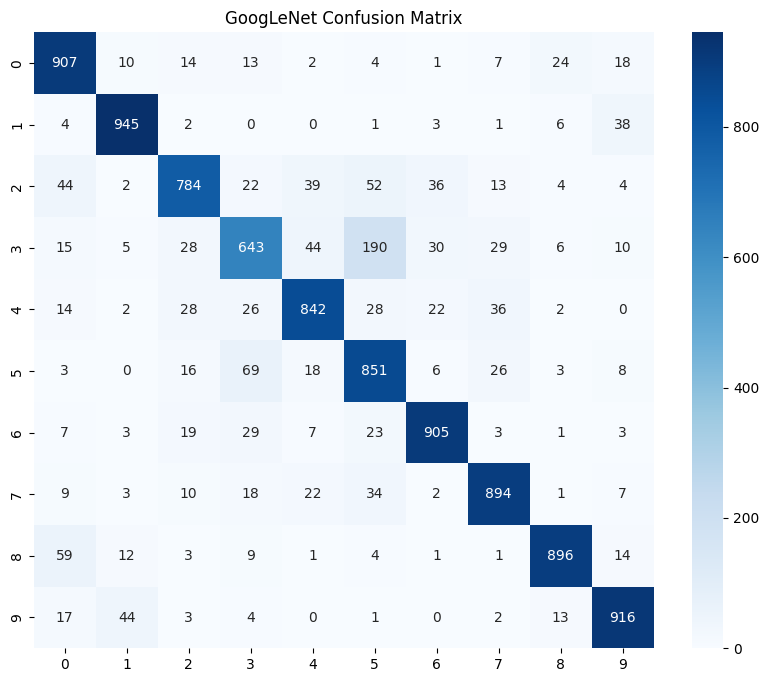

In [9]:
# Confusion Matrix
all_predictions = model.predict(test_images, batch_size=BATCH_SIZE)
all_pred_classes = np.argmax(all_predictions, axis=1)
all_true_classes = np.argmax(test_labels, axis=1)
cm = confusion_matrix(all_true_classes, all_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('GoogLeNet Confusion Matrix')
plt.show()